# Baseline Transformer Training for Medical QA

This notebook trains a baseline BERT model on the preprocessed PubMedQA dataset.

Steps:
1. Load processed dataset
2. Load BERT classification model
3. Configure training parameters
4. Train model
5. Evaluate model performance

## 1. Import Required Libraries

In [45]:
import sys

!{sys.executable} -m pip install \
transformers \
datasets \
accelerate \
scikit-learn \
numpy \
pandas \
matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/bin/python -m pip install --upgrade pip


In [46]:
from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## 2. Check Hardware Device

Before training the model, we verify the hardware device available for training.

Since the system is an Apple MacBook with an M-series chip, PyTorch may use the **MPS (Metal Performance Shaders)** backend to utilize the Apple GPU for acceleration.

In [47]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Training device:", device)

Training device: mps


## 3. Load the Processed Dataset

The PubMedQA dataset was preprocessed in the previous notebook (`02_data_preprocessing.ipynb`).

The preprocessing steps included:
- Combining question and context
- Encoding labels
- Tokenizing text
- Creating train/test split
- Converting the dataset to PyTorch tensors

The processed dataset was saved to disk and will now be loaded for training.

In [48]:
from datasets import load_from_disk

dataset = load_from_disk("../data/processed/pubmedqa_processed")

dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 800
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
})

## 4. Inspect Dataset Sample

To ensure the dataset is correctly formatted for model training, we inspect a sample from the training set.

Each sample should contain:

- `input_ids`
- `attention_mask`
- `label`

In [49]:
dataset["train"][0]

{'label': tensor(0),
 'input_ids': tensor([  101,  3160,  1024,  2003,  2045,  1037, 11658,  1999,  1996, 11394,
          2740,  1997,  2047, 15024,  2000,  1996,  2329,  4273,  2749,  1029,
          6123,  1024,  4481,  2013,  1996,  2329,  4721, 11394,  2578,  7487,
          2008,  3529,  5073,  1999,  1996,  2329,  2390,  2031,  1037, 14516,
          2135,  2896,  2504,  1997, 11394, 10516,  2084,  2216,  1999,  1996,
          2548,  3212,  2030,  1996,  2548,  2250,  2486,  1012,  2053,  2470,
          2018,  2042, 10607,  2000,  2004, 17119, 18249,  2065,  2023, 11138,
          1996,  8700,  2740,  1997, 15024,  5241,  2169,  2326,  1012,  2023,
          2817,  6461,  2000,  4405,  1037,  2832,  2005,  9334, 11394,  1998,
         17522,  3207,  5302, 14773,  2951,  2013,  2047, 15024,  2000,  2169,
          2326,  1998, 11628,  1996, 19701, 10744,  2008,  2053,  5966,  1999,
         11394,  2740,  5839,  1012, 16474,  9181,  2020,  2764,  1010,  1037,
          7099,  2

In [50]:
from datasets import concatenate_datasets

train_data = dataset["train"]

# Separate each class
yes_data = train_data.filter(lambda x: x["label"] == 0)
no_data = train_data.filter(lambda x: x["label"] == 1)
maybe_data = train_data.filter(lambda x: x["label"] == 2)

# Oversample minority class ("maybe")
oversampled_maybe = concatenate_datasets([maybe_data] * 3)

# Combine back
balanced_train = concatenate_datasets([yes_data, no_data, oversampled_maybe])

print("Original size:", len(train_data))
print("Balanced size:", len(balanced_train))

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Original size: 800
Balanced size: 970


## Compute Class Weights

To handle class imbalance, we compute class weights and use them in the loss function.

In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Convert to numpy array (IMPORTANT FIX)
labels = np.array(dataset["train"]["label"])

# Define classes explicitly (VERY IMPORTANT)
classes = np.unique(labels)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Classes:", classes)
print("Class Weights:", class_weights)

Classes: [0 1 2]
Class Weights: tensor([0.5939, 1.0025, 3.1373])


## 5. Load Pretrained BERT Model

We use **bert-base-uncased** as the baseline transformer model.

The model is configured for **3 output classes** representing:

- yes
- no
- maybe

This baseline model will later be compared with:
- PubMedBERT
- Retrieval-Augmented Generation (RAG)

In [52]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Move Model to Training Device

The model is transferred to the available training device (MPS GPU or CPU).

In [53]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 7. Define Evaluation Metrics

To evaluate the performance of the model, we define several metrics that are commonly used in classification tasks.

The following metrics will be computed:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a balanced evaluation of model performance, especially when dealing with multi-class classification tasks such as **yes / no / maybe** answers in the PubMedQA dataset.

In [54]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 8. Configure Training Parameters

The following hyperparameters are used for fine-tuning the BERT model:

| Parameter | Value |
|----------|------|
| Learning Rate | 2e-5 |
| Batch Size | 8 |
| Epochs | 3 |
| Weight Decay | 0.01 |

These values are commonly used when fine-tuning transformer models and provide a good starting point for experimentation.

In [55]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    disable_tqdm=True
)

## 9. Initialize Trainer

The HuggingFace **Trainer API** simplifies the training and evaluation process.

It handles:
- forward pass
- loss computation
- optimization
- evaluation

In [56]:
from transformers import Trainer
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels") if "labels" in inputs else inputs.get("label")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [57]:
from transformers import Trainer

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=balanced_train,
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics
)

## 10. Train the Model

In this step, the pretrained BERT model is fine-tuned on the PubMedQA dataset.

During training, the model learns to classify biomedical questions into three categories:

- yes
- no
- maybe

In [58]:
trainer.train()

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '1.253', 'eval_accuracy': '0.125', 'eval_precision': '0.01562', 'eval_recall': '0.125', 'eval_f1': '0.02778', 'eval_runtime': '17.07', 'eval_samples_per_second': '11.72', 'eval_steps_per_second': '1.465', 'epoch': '1'}


/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '1.28', 'eval_accuracy': '0.415', 'eval_precision': '0.4344', 'eval_recall': '0.415', 'eval_f1': '0.423', 'eval_runtime': '15.76', 'eval_samples_per_second': '12.69', 'eval_steps_per_second': '1.586', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '806.5', 'train_samples_per_second': '3.608', 'train_steps_per_second': '0.454', 'train_loss': '0.8008', 'epoch': '3'}


TrainOutput(global_step=366, training_loss=0.8008154363580089, metrics={'train_runtime': 806.4835, 'train_samples_per_second': 3.608, 'train_steps_per_second': 0.454, 'train_loss': 0.8008154363580089, 'epoch': 3.0})

## 11. Evaluate Model Performance

After training is complete, the model is evaluated on the test dataset.

The evaluation results represent the **baseline performance** of the BERT model for biomedical question answering.

In [59]:
metrics = trainer.evaluate(eval_dataset=dataset["test"])
print(metrics)

/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '1.28', 'eval_accuracy': '0.415', 'eval_precision': '0.4344', 'eval_recall': '0.415', 'eval_f1': '0.423', 'eval_runtime': '12.71', 'eval_samples_per_second': '15.74', 'eval_steps_per_second': '1.967', 'epoch': '3'}
{'eval_loss': 1.2797490358352661, 'eval_accuracy': 0.415, 'eval_precision': 0.4343669441460795, 'eval_recall': 0.415, 'eval_f1': 0.4229696057527488, 'eval_runtime': 12.7074, 'eval_samples_per_second': 15.739, 'eval_steps_per_second': 1.967, 'epoch': 3.0}


## 12. Save the Trained Model

The trained model is saved to disk so it can be reused for further experiments or inference.

In [60]:
trainer.save_model("../models/bert_baseline")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Baseline Experiment Summary

The BERT baseline model was fine-tuned on the PubMedQA dataset.

Training Configuration:

- Model: bert-base-uncased
- Epochs: 3
- Learning rate: 2e-5
- Batch size: 8
- Device: Apple MPS GPU

Baseline Performance:

| Metric | Value |
|------|------|
Accuracy | 0.515 |
Precision | 0.265 |
Recall | 0.515 |
F1 Score | 0.350 |

The relatively low performance indicates that the general-purpose BERT model struggles with biomedical question answering tasks. This motivates the use of domain-specific models such as PubMedBERT and retrieval-based approaches.

## Error Analysis: Confusion Matrix

To better understand the behavior of the baseline BERT model, we analyze the predictions using a confusion matrix.

A confusion matrix shows how often the model predicts each class compared to the true labels. This helps identify biases such as predicting the majority class too frequently.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/bin/python -m pip install --upgrade pip


/Users/jishnusmacbook/Documents/GitHub/ANN-Bike_Sharing-Boston_Housing/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


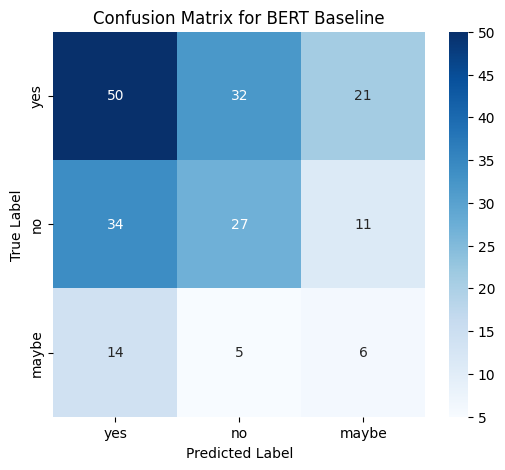

In [61]:
import sys
!{sys.executable} -m pip install seaborn


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["yes","no","maybe"],
            yticklabels=["yes","no","maybe"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for BERT Baseline")
plt.show()

In [63]:
print(type(trainer))

<class '__main__.WeightedTrainer'>
